# NB3: Data Splitting Methods

How we divide the data into train, validation, and test sets affects whether the
evaluation score is trustworthy. This notebook compares a simple temporal split
with a cyclic time-block split, and looks at how each one distributes the data.

The split chosen here is saved for use in NB4 onwards.

In [ ]:
# ============================================================
# Colab setup — run this cell FIRST. Does nothing when run locally.
# ============================================================
import os, sys, shutil

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1) Clone repo (or pull if already cloned)
    if not os.path.exists("/content/ML_TND"):
        os.system("git clone -q https://github.com/lotteat11/ML_TND /content/ML_TND")
    else:
        os.system("cd /content/ML_TND && git pull -q")

    # 2) Install Python deps
    os.system("pip install -q xgboost scikit-learn pyarrow joblib")

    # 3) Download parquet from GitHub Releases (wget follows redirects reliably)
    dest = "/content/ML_TND/grace_workshop_small.parquet"
    if not os.path.exists(dest):
        print("Downloading grace_workshop_small.parquet (~257 MB)...")
        ret = os.system(
            f"wget -q --show-progress -O {dest} "
            "https://github.com/lotteat11/ML_TND/releases/download/v1.0-workshop/grace_workshop_small.parquet"
        )
        if ret != 0 or not os.path.exists(dest):
            raise RuntimeError("Download failed. Check your internet connection and re-run this cell.")
        print("Download complete.")

    # 4) chdir into workshop/ so all relative paths resolve
    os.chdir("/content/ML_TND/workshop")
    print("Setup complete — ready to run.")
else:
    print("Local run — no setup needed.")


In [56]:
# Install required packages — safe to run even if already installed
%pip install -q xgboost scikit-learn pandas numpy matplotlib scipy joblib pyarrow

Python(40519) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Load libraries including `joblib` for saving the model to disk.

In [57]:
import sys, joblib
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import feature_functions as ff
from paths import GRACE_WORKSHOP as GRACE_MERGED

Load the data and apply the same feature engineering pipeline as NB2.

In [58]:
# Load and engineer — same pipeline as NB2
df = pd.read_parquet(GRACE_MERGED)
df['time'] = pd.to_datetime(df['grace_time'])
df = df[(df['time'] > '2009-06-01') & (df['time'] < '2016-01-01')].sort_values('time').reset_index(drop=True)
df = df[(df['rho_obs'] > 0) & (df['msis_rho'] > 0)].reset_index(drop=True)
df['log_ratio'] = np.log(df['rho_obs'] / df['msis_rho'])

df = ff.add_lst_doy_features(df)
df['lon_sin']           = np.sin(np.deg2rad(df['lon']))
df['lon_cos']           = np.cos(np.deg2rad(df['lon']))
df['lst_lat_sin']       = df['lst_sin'] * df['lat']
df['vtec_matched_lag']  = df['matched_tec_value'].shift(500)
df['vtec_matched_lag2'] = df['matched_tec_value'].shift(17280)
df = df.dropna().reset_index(drop=True)

FEATURES = ['f107', 'f107a', 'ap_m3h', 'ap_m6h', 'alt_km', 'lat',
            'matched_tec_value', 'lst_sin', 'lst_cos', 'doy_sin', 'doy_cos',
            'lon_sin', 'lon_cos', 'vtec_matched_lag', 'vtec_matched_lag2', 'lst_lat_sin']
COLS_TO_SCALE = ['f107', 'f107a', 'ap_m3h', 'ap_m6h', 'alt_km', 'lat',
                 'matched_tec_value', 'vtec_matched_lag', 'vtec_matched_lag2']
TARGET = 'log_ratio'
PLOT_FEATURES = ['alt_km', 'f107', 'ap_m3h', TARGET]

print(f'Loaded and engineered {len(df):,} rows')

Loaded and engineered 3,967,169 rows


## 1. Look at the data over the full mission

Before splitting, plot the observed density and the MSIS density across the whole period.
Watch how the overall level of the signal changes from the start of the mission to the end.

In [66]:
def plot_split_distributions(df, mask, cols, title):
    """Overlay train/val/test distributions using histograms (fast)."""
    n_cols = 4
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
    axes = axes.flatten()

    names   = {0: 'Train', 1: 'Val', 2: 'Test'}
    colours = {0: 'C0',    1: 'C2',  2: 'C3'}

    for ax, col in zip(axes, cols):
        for k in (0, 1, 2):
            vals = df.loc[mask == k, col].dropna().values[::200]
            ax.hist(vals, bins=40, density=True, alpha=0.5,
                    color=colours[k], label=names[k])
        ax.set_title(col, fontsize=9)
        ax.set_ylabel('')
        ax.legend(fontsize=7)

    for ax in axes[len(cols):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


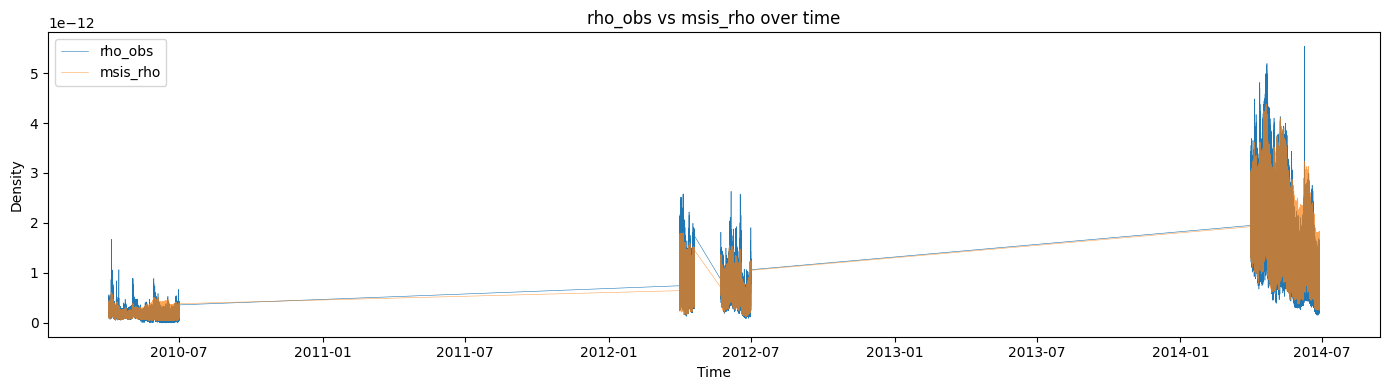

In [ ]:
# Observed vs MSIS density across the full mission
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['time'][::50], df['rho_obs'][::50],  lw=0.4, label='rho_obs',  color='C0')
ax.plot(df['time'][::50], df['msis_rho'][::50], lw=0.4, label='msis_rho', color='C1', alpha=0.7)
ax.set_ylabel('Density')
ax.set_xlabel('Time')
ax.set_title('rho_obs vs msis_rho over time')
ax.legend()
plt.tight_layout()
plt.show()

## 2. The standard split — simple temporal

The usual default: train on the first 70% in time, validate on the next 15%, test on the last 15%.
Three contiguous blocks, in order.

After making the split, compare the distribution of the target and the densities across the
three sets. For the model to be evaluated fairly, train / val / test should cover similar ranges.
Do they?

In [ ]:
def plot_stacked_with_split(df, mask, title="", feature_cols=None):
    """Plot time-series features coloured by train/val/test assignment."""
    if feature_cols is None:
        feature_cols = ["f107", "ap_m3h", "matched_tec_value"]
    colors = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868", -1: "#cccccc"}
    labels = {0: "Train", 1: "Val", 2: "Test", -1: "Gap"}

    fig, axes = plt.subplots(len(feature_cols), 1, figsize=(14, 2.5 * len(feature_cols)), sharex=True)
    if len(feature_cols) == 1:
        axes = [axes]

    t = df["time"].values
    for ax, col in zip(axes, feature_cols):
        vals = df[col].values
        for split_val, color in colors.items():
            m = mask == split_val
            if m.any():
                ax.scatter(t[m], vals[m], s=0.2, color=color,
                           label=labels[split_val] if col == feature_cols[0] else "")
        ax.set_ylabel(col, fontsize=9)
        ax.tick_params(labelsize=8)

    axes[0].legend(markerscale=8, fontsize=9, loc="upper right")
    axes[0].set_title(title, fontsize=11)
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()


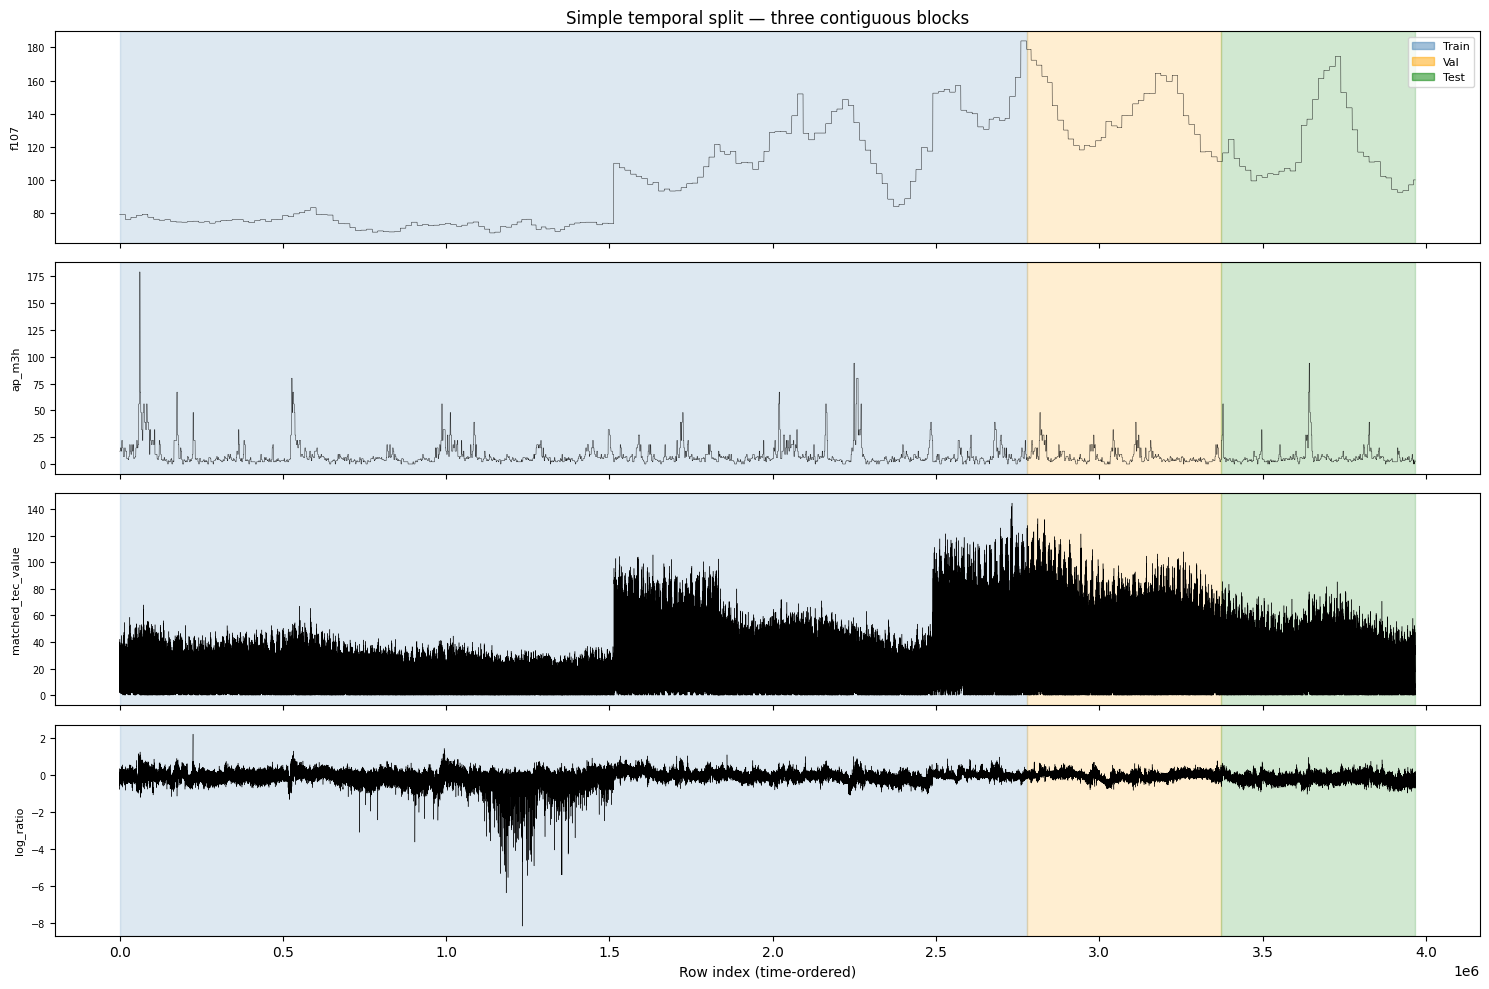

In [61]:
# ── PARAMETERS ──────────────────────────────────────────────────────────────
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
N_CYCLES   = 8     # for cyclic split below
GAP        = 1100  # gap rows between blocks in cyclic split

MAX_DEPTH     = 4
N_ESTIMATORS  = 500
LEARNING_RATE = 0.05
# ────────────────────────────────────────────────────────────────────────────

n = len(df)
n_train = int(n * TRAIN_FRAC)
n_val   = int(n * (TRAIN_FRAC + VAL_FRAC))

mask_temporal = np.full(n, -1, dtype=int)
mask_temporal[:n_train] = 0
mask_temporal[n_train:n_val] = 1
mask_temporal[n_val:] = 2

plot_stacked_with_split(df, mask_temporal,
                        title="Simple temporal split — three contiguous blocks",
                        feature_cols=["f107", "ap_m3h", "matched_tec_value"])

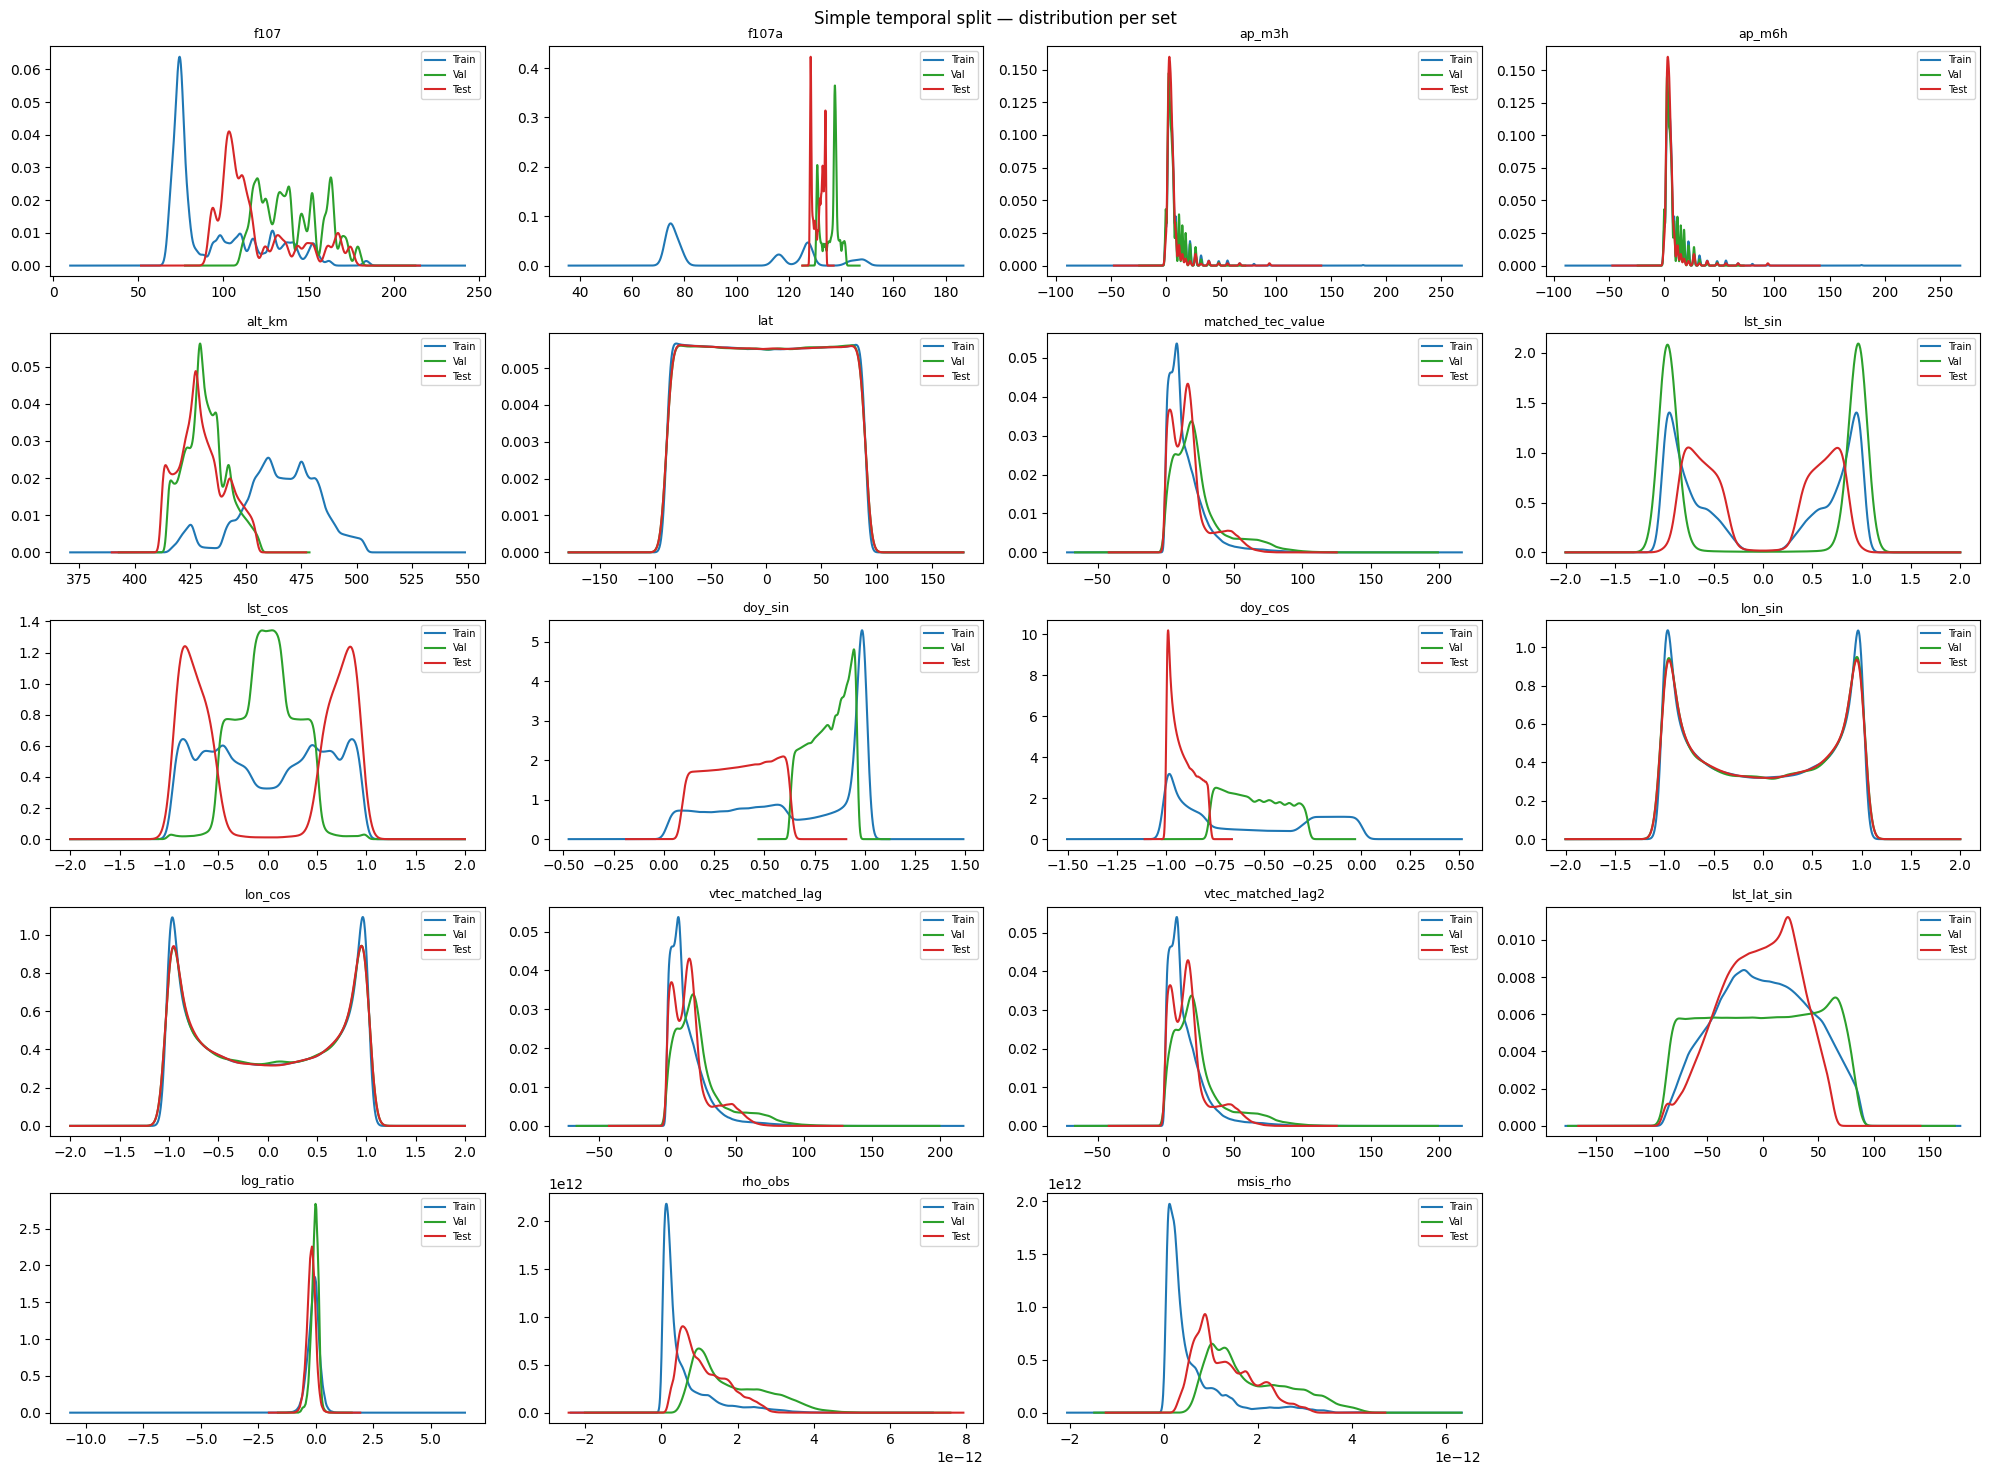

In [67]:
# Do the train/val/test distributions overlap under the simple temporal split?
plot_split_distributions(df, mask_temporal,
                         FEATURES + ['log_ratio', 'rho_obs', 'msis_rho'],
                         'Simple temporal split — distribution per set')

Train XGBoost on the temporal split and compute RMSE.

In [63]:
X = df[FEATURES]
y = df[[TARGET]]

X_tr = X.iloc[:n_train];      y_tr = y.iloc[:n_train]
X_va = X.iloc[n_train:n_val]; y_va = y.iloc[n_train:n_val]
X_te = X.iloc[n_val:];        y_te = y.iloc[n_val:]

scaler_t = MinMaxScaler((-1, 1)).fit(X_tr[COLS_TO_SCALE])

def apply_scaler(X_df, scaler):
    Xs = X_df.copy()
    Xs[COLS_TO_SCALE] = scaler.transform(X_df[COLS_TO_SCALE])
    return Xs

Xtr_s = apply_scaler(X_tr, scaler_t)
Xva_s = apply_scaler(X_va, scaler_t)
Xte_s = apply_scaler(X_te, scaler_t)

model_t = xgb.XGBRegressor(
    max_depth=MAX_DEPTH, n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE,
    subsample=0.5, colsample_bytree=0.6, min_child_weight=300,
    tree_method='hist', n_jobs=-1, early_stopping_rounds=20, verbosity=0,
)
model_t.fit(Xtr_s, y_tr.values.ravel(), eval_set=[(Xva_s, y_va.values.ravel())], verbose=False)

# RMSE in physical density space: rho = msis_rho * exp(log_ratio)
def density_rmse(model, X_sc, idx):
    pred_log = model.predict(X_sc)
    rho_pred = df.loc[idx, 'msis_rho'].values * np.exp(pred_log)
    return root_mean_squared_error(df.loc[idx, 'rho_obs'].values, rho_pred)

rmse_t = {
    'train': density_rmse(model_t, Xtr_s, X_tr.index),
    'val':   density_rmse(model_t, Xva_s, X_va.index),
    'test':  density_rmse(model_t, Xte_s, X_te.index),
}
print('Temporal split RMSE [kg/m³]:', {k: f'{v:.3e}' for k, v in rmse_t.items()})

Temporal split RMSE [kg/m³]: {'train': '1.096e-13', 'val': '2.881e-13', 'test': '2.046e-13'}


## 3. Cyclic time-block split

Instead of three big blocks, repeat `[train | gap | val | gap | test]` across the whole
time range — 8 cycles, with a 1100-row buffer between segments.

Make the same distribution comparison as before. How do the train / val / test
distributions compare now?

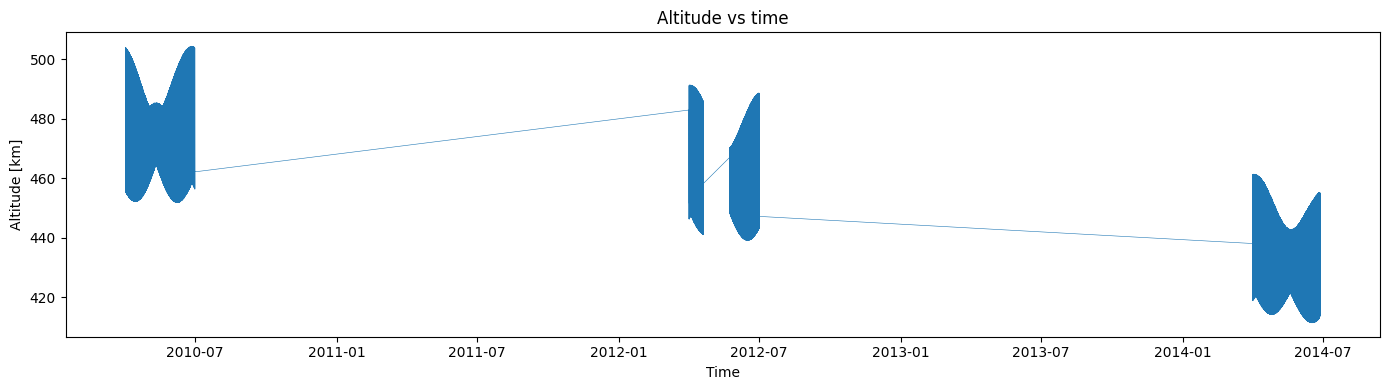

In [64]:
# Altitude over time
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['time'][::50], df['alt_km'][::50], lw=0.4, color='C0')
ax.set_ylabel('Altitude [km]')
ax.set_xlabel('Time')
ax.set_title('Altitude vs time')
plt.tight_layout()
plt.show()


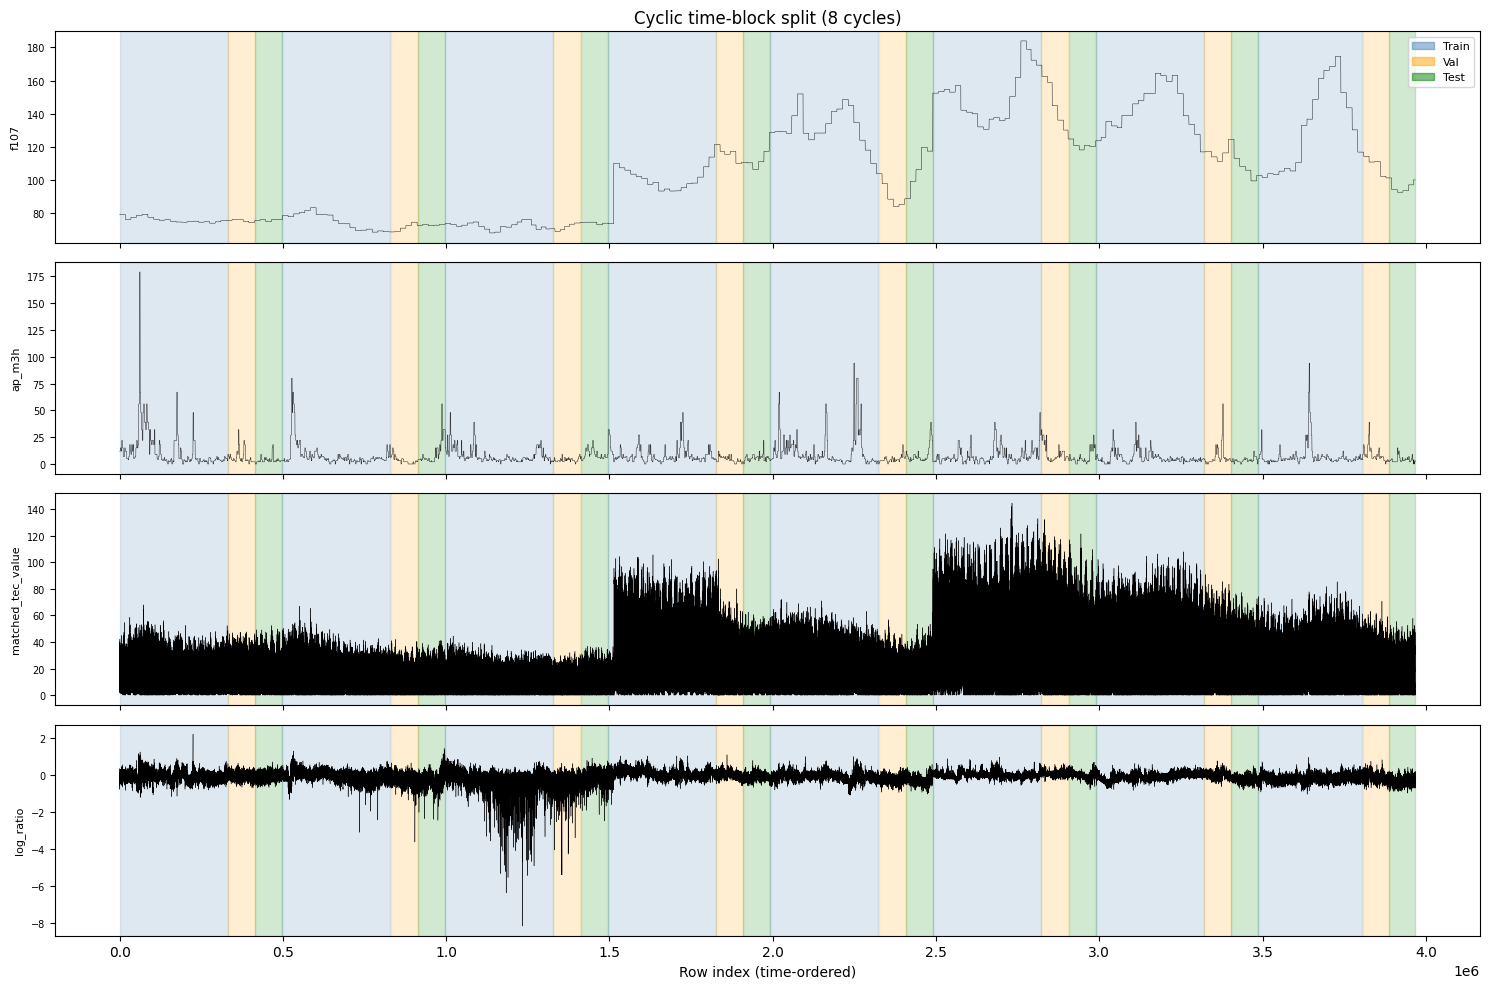

In [45]:
X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c, \
    idx_train_c, idx_val_c, idx_test_c = ff.timeblock_split_repeated(
        X, y,
        fractions=(2/3, 1/6, 1/6),
        n_cycles=N_CYCLES,
        gap_before_val=GAP,
        gap_before_test=GAP,
        order=('train', 'test', 'val'),
        copy=False,
    )

# Build mask for visualisation
mask_cyclic = np.full(n, -1, dtype=int)
mask_cyclic[np.searchsorted(df.index, idx_train_c)] = 0
mask_cyclic[np.searchsorted(df.index, idx_val_c)]   = 1
mask_cyclic[np.searchsorted(df.index, idx_test_c)]  = 2

plot_stacked_with_split(df, mask_cyclic,
                        title=f'Cyclic time-block split ({N_CYCLES} cycles)',
                        feature_cols=['f107', 'ap_m3h', 'matched_tec_value'])

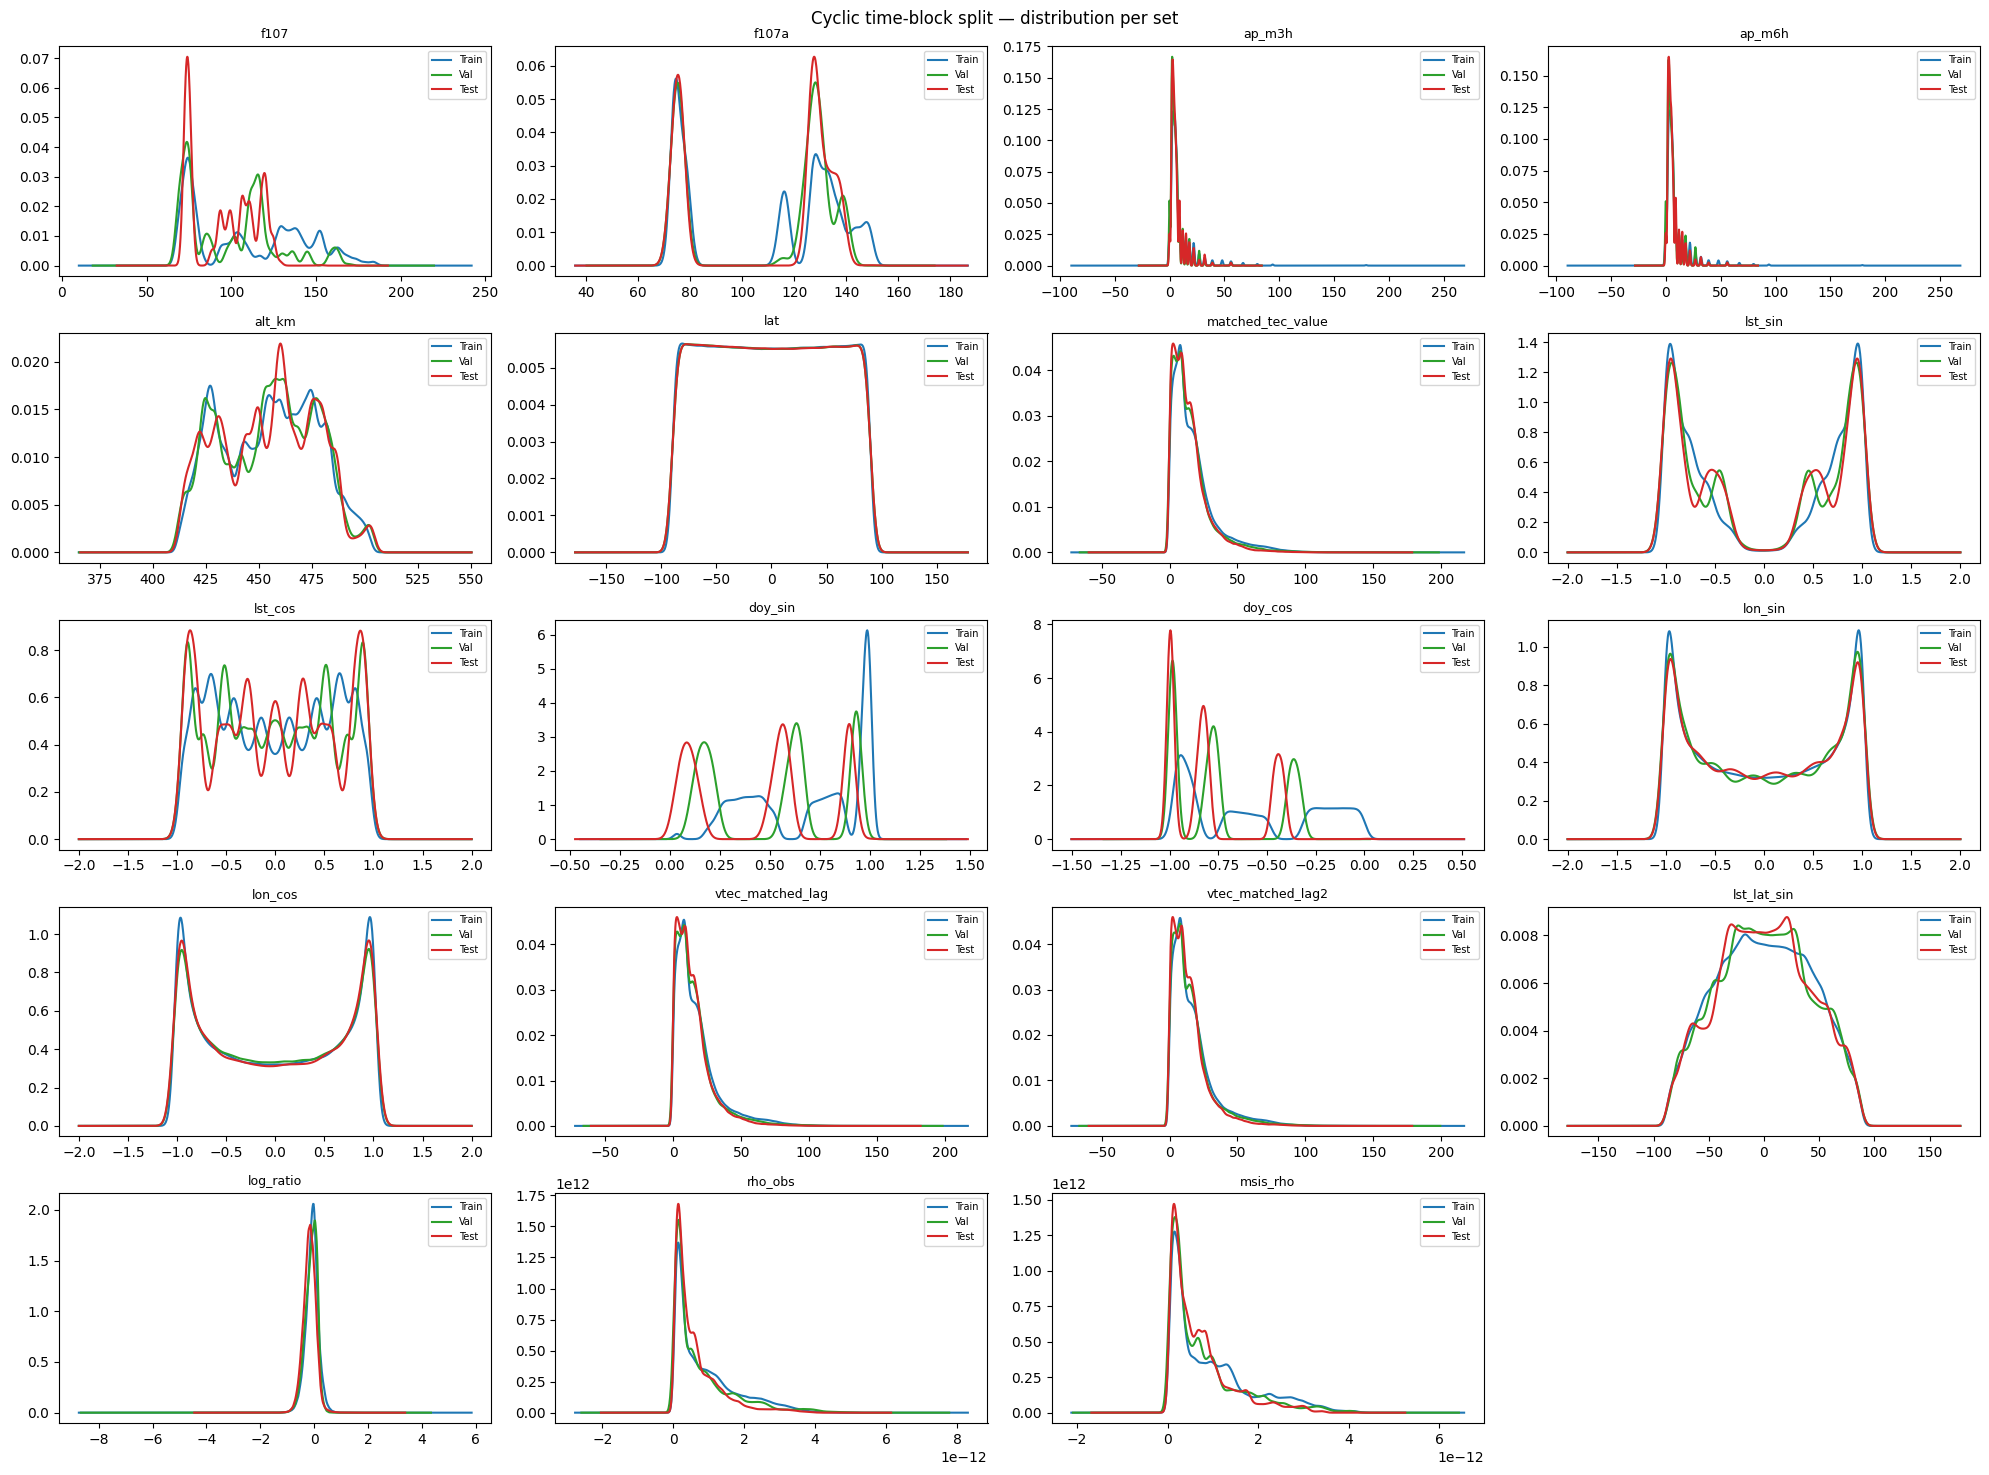

In [68]:
# Same distribution check, now under the cyclic split
plot_split_distributions(df, mask_cyclic,
                         FEATURES + ['log_ratio', 'rho_obs', 'msis_rho'],
                         'Cyclic time-block split — distribution per set')

Train XGBoost on the cyclic split and compute RMSE.

In [69]:
scaler_c = MinMaxScaler((-1, 1)).fit(X_train_c[COLS_TO_SCALE])
Xtr_c = apply_scaler(X_train_c, scaler_c)
Xva_c = apply_scaler(X_val_c,   scaler_c)
Xte_c = apply_scaler(X_test_c,  scaler_c)

model_c = xgb.XGBRegressor(
    max_depth=MAX_DEPTH, n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE,
    subsample=0.5, colsample_bytree=0.6, min_child_weight=300,
    tree_method='hist', n_jobs=-1, early_stopping_rounds=20, verbosity=0,
)
model_c.fit(Xtr_c, y_train_c.values.ravel(),
            eval_set=[(Xva_c, y_val_c.values.ravel())], verbose=False)

rmse_c = {
    'train': density_rmse(model_c, Xtr_c, idx_train_c),
    'val':   density_rmse(model_c, Xva_c, idx_val_c),
    'test':  density_rmse(model_c, Xte_c, idx_test_c),
}
print('Cyclic split RMSE [kg/m³]:', {k: f'{v:.3e}' for k, v in rmse_c.items()})

Cyclic split RMSE [kg/m³]: {'train': '1.331e-13', 'val': '1.579e-13', 'test': '1.439e-13'}


In [ ]:
# Cyclic split validation — full period (every 10th point)
val_idx        = idx_val_c
obs_val        = df.loc[val_idx, 'rho_obs'].values
msis_val       = df.loc[val_idx, 'msis_rho'].values
time_val       = df.loc[val_idx, 'time'].values
pred_val_log   = model_c.predict(apply_scaler(X_val_c, scaler_c))
rho_pred_val_c = msis_val * np.exp(pred_val_log)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_val[::10], obs_val[::10],        lw=0.5, label='Observed',  color='black')
ax.plot(time_val[::10], msis_val[::10],       lw=0.5, label='MSIS',      color='C1', alpha=0.8)
ax.plot(time_val[::10], rho_pred_val_c[::10], lw=0.5, label='Predicted', color='C0', alpha=0.9)
ax.set_yscale('log'); ax.set_ylabel('ρ [kg m⁻³]'); ax.set_xlabel('Time')
ax.set_title('Cyclic split — val set: full period'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [ ]:
# Cyclic split validation — 3-day zoom
t_end3 = pd.Timestamp(time_val[0]) + pd.Timedelta(days=3)
m3 = pd.to_datetime(time_val) < t_end3
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_val[m3], obs_val[m3],        lw=0.8, label='Observed',  color='black')
ax.plot(time_val[m3], msis_val[m3],       lw=0.8, label='MSIS',      color='C1', alpha=0.8)
ax.plot(time_val[m3], rho_pred_val_c[m3], lw=0.8, label='Predicted', color='C0', alpha=0.9)
ax.set_yscale('log'); ax.set_ylabel('ρ [kg m⁻³]'); ax.set_xlabel('Time')
ax.set_title('Cyclic split — val set: 3-day zoom'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


Plot the RMSE for all three split strategies side by side.

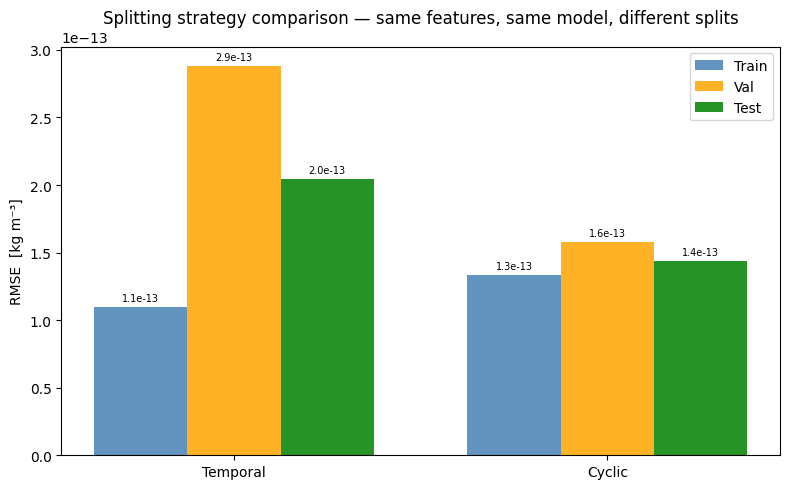

In [70]:
strategies  = ['Temporal', 'Cyclic']
all_rmse    = [rmse_t, rmse_c]
split_names = ['train', 'val', 'test']
colors_bar  = ['steelblue', 'orange', 'green']

x     = np.arange(len(strategies))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, (split, color) in enumerate(zip(split_names, colors_bar)):
    vals = [rmse[split] for rmse in all_rmse]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=split.capitalize(), color=color, alpha=0.85)
    ax.bar_label(bars, fmt='{:.1e}', padding=3, fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_ylabel('RMSE  [kg m⁻³]')
ax.set_title('Splitting strategy comparison — same features, same model, different splits')
ax.legend()
plt.tight_layout()
plt.show()

Save the trained cyclic-split model and scaler to disk so NB4 can load them.

Compute RMSE, MAPE, and R² in physical density space for each split strategy (val set).

In [71]:
from sklearn.metrics import r2_score

def density_metrics(rho_obs, rho_pred, label):
    mask = rho_obs > 0
    obs, pred = rho_obs[mask], rho_pred[mask]
    rmse = np.sqrt(np.mean((obs - pred) ** 2))
    mape = np.mean(np.abs((obs - pred) / obs)) * 100
    return {'Strategy': label, 'RMSE [kg/m³]': f'{rmse:.3e}',
            'MAPE [%]': f'{mape:.1f}', 'R²': f'{r2_score(obs, pred):.3f}'}

def model_density(model, X_sc, idx):
    pred_log = model.predict(X_sc)
    return df.loc[idx, 'msis_rho'].values * np.exp(pred_log)

# Compare the two strategies on their own validation sets
rows = [
    density_metrics(df.loc[X_va.index, 'rho_obs'].values, df.loc[X_va.index, 'msis_rho'].values, 'MSIS (val)'),
    density_metrics(df.loc[X_va.index, 'rho_obs'].values, model_density(model_t, Xva_s, X_va.index), 'Temporal model'),
    density_metrics(df.loc[idx_val_c, 'rho_obs'].values,  model_density(model_c, Xva_c, idx_val_c),  'Cyclic model'),
]
pd.DataFrame(rows).set_index('Strategy')

,RMSE [kg/m³],MAPE [%],R²
Strategy,,,
MSIS (val),2.639e-13,12.9,0.923
Temporal model,2.881e-13,12.7,0.908
Cyclic model,1.579e-13,14.6,0.968


In [72]:
# Save cyclic model + scaler for NB4
model_c.get_booster().save_model("nb3_model_cyclic.json")
joblib.dump(scaler_c, "nb3_scaler_cyclic.joblib")
print("Saved nb3_model_cyclic.json and nb3_scaler_cyclic.joblib")

Saved nb3_model_cyclic.json and nb3_scaler_cyclic.joblib


## Try this

1. Compare the distribution plots for the temporal split and the cyclic split.
   For which split do the train / val / test curves line up best?
2. Look at the RMSE bar chart. Which split gives the smaller gap between train and test?
3. Change `N_CYCLES` to 4, then 16. How does it affect the distribution overlap?
4. Change `GAP` to 0 (no buffer between blocks). Does the score change?

The split saved below is used by NB4 and NB5.

## Your turn — experiment

Change the settings below and rerun this cell to try to get the lowest **validation** RMSE.
You can switch the split, drop features, and adjust the hyperparameters.
Each run prints its score and keeps track of the best you have reached so far.

In [ ]:
# ── SANDBOX — change anything, then rerun this cell ──────────────────────────
SPLIT         = 'temporal'    # 'temporal' or 'cyclic'
N_CYCLES_SB   = 7             # only used when SPLIT == 'cyclic'
DROP_FEATURES = []            # e.g. ['f107a', 'lon'] to remove features
MAX_DEPTH_SB     = 4
N_ESTIMATORS_SB  = 300        # keep low for speed — early stopping will find the best
LEARNING_RATE_SB = 0.05
# ─────────────────────────────────────────────────────────────────────────────

feats_sb = [f for f in FEATURES if f not in DROP_FEATURES]

if SPLIT == 'cyclic':
    X_tr, X_va, X_te, y_tr, y_va, y_te, idx_tr, idx_va, idx_te = ff.timeblock_split_repeated(
        X[feats_sb], y, fractions=(2/3, 1/6, 1/6),
        n_cycles=N_CYCLES_SB, gap_before_val=GAP, gap_before_test=GAP,
        order=('train', 'test', 'val'), copy=False,
    )
else:
    n = len(X)
    n_train = int(n * TRAIN_FRAC); n_val = int(n * (TRAIN_FRAC + VAL_FRAC))
    X_tr = X[feats_sb].iloc[:n_train];  X_va = X[feats_sb].iloc[n_train:n_val]; X_te = X[feats_sb].iloc[n_val:]
    y_tr = y.iloc[:n_train];            y_va = y.iloc[n_train:n_val];            y_te = y.iloc[n_val:]
    idx_tr, idx_va, idx_te = X_tr.index, X_va.index, X_te.index

scaler_sb = MinMaxScaler((-1, 1)).fit(X_tr[COLS_TO_SCALE])
def scale_sb(d):
    d = d.copy(); d[COLS_TO_SCALE] = scaler_sb.transform(d[COLS_TO_SCALE]); return d

model_sb = xgb.XGBRegressor(
    n_estimators=N_ESTIMATORS_SB, max_depth=MAX_DEPTH_SB,
    learning_rate=LEARNING_RATE_SB, objective='reg:squarederror',
    early_stopping_rounds=30, eval_metric='rmse', verbosity=0,
)
model_sb.fit(scale_sb(X_tr), y_tr.values.ravel(),
             eval_set=[(scale_sb(X_va), y_va.values.ravel())], verbose=False)

def rmse_density_sb(idx):
    rho_obs  = df.loc[idx, 'rho_obs'].values
    rho_pred = df.loc[idx, 'msis_rho'].values * np.exp(model_sb.predict(scale_sb(X[feats_sb].loc[idx])))
    return float(np.sqrt(np.mean((rho_obs - rho_pred) ** 2)))

rmse_tr = rmse_density_sb(idx_tr)
rmse_va = rmse_density_sb(idx_va)
rmse_te = rmse_density_sb(idx_te)

print(f"Split={SPLIT}  depth={MAX_DEPTH_SB}  lr={LEARNING_RATE_SB}  trees={model_sb.best_iteration}")
print(f"  Train: {rmse_tr:.3e}  |  Val: {rmse_va:.3e}  |  Test: {rmse_te:.3e}  [kg m\u207b\u00b3]")

# Track best across reruns
import builtins
best = getattr(builtins, '_best_val_rmse_sb', float('inf'))
if rmse_va < best:
    builtins._best_val_rmse_sb = rmse_va
    print(f"  \u2b50 New best val RMSE: {rmse_va:.3e}")
else:
    print(f"  Best so far: {best:.3e}  (no improvement)")


This run  val RMSE: 2.881e-13 kg/m³   (split=temporal, depth=4, n_est=1500, lr=0.05, dropped=none)
Best so far:        1.178e-13 kg/m³   (split=cyclic, depth=4, n_est=500, lr=0.05, dropped=none)
